# Influence des infrastructures et aménagements routiers
# -> Peut t'on predire la severite d'un accident

In [1]:
from pyspark.sql import SparkSession

spark = SparkSession.builder\
    .master("local[*]")\
    .appName("Accident")\
    .config("spark.driver.memory", "4g") \
    .getOrCreate()

spark.sparkContext.setLogLevel("ERROR")

your 131072x1 screen size is bogus. expect trouble
25/06/18 11:10:23 WARN Utils: Your hostname, DESKTOP-NHT3FJU resolves to a loopback address: 127.0.1.1; using 10.255.255.254 instead (on interface lo)
25/06/18 11:10:23 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/06/18 11:10:24 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [2]:
df = spark.read.parquet("../../data/processed_accidents_v2.parquet/")
df.show(5, truncate=False)

+--------+-------------------+-------------------+---------+-----------+------------------+---------------+-----------+-----+--------------+-------------+-----------+------------+--------------+--------------+---------------+-----------------+-----------------+-------+----+--------+--------+--------+-------+-------+----------+-------+----+---------------+--------------+------------+--------------+--------------+-----------------+---------------------+
|Severity|Start_Time         |End_Time           |Start_Lat|Start_Lng  |Distance(mi)      |City           |County     |State|Temperature(F)|Wind_Chill(F)|Humidity(%)|Pressure(in)|Visibility(mi)|Wind_Direction|Wind_Speed(mph)|Precipitation(in)|Weather_Condition|Amenity|Bump|Crossing|Give_Way|Junction|No_Exit|Railway|Roundabout|Station|Stop|Traffic_Calming|Traffic_Signal|Turning_Loop|Sunrise_Sunset|Civil_Twilight|Nautical_Twilight|Astronomical_Twilight|
+--------+-------------------+-------------------+---------+-----------+----------------

## Preprocess

On ne garde que les colonnes qui semblent importante pour la prediction de la severite d'un accident

In [3]:
columns_to_keep = [
    "Severity",

    'Start_Lat', 'Start_Lng', 'Distance(mi)',

    'Temperature(F)', 'Wind_Chill(F)', 'Humidity(%)',
    'Pressure(in)', 'Visibility(mi)', 'Wind_Speed(mph)', 'Precipitation(in)',

    'Amenity', 'Bump', 'Crossing', 'Give_Way', 'Junction', 'No_Exit',
    'Railway', 'Roundabout', 'Station', 'Stop', 'Traffic_Calming',
    'Traffic_Signal', 'Turning_Loop',

    'Sunrise_Sunset', 'Civil_Twilight',
    'Nautical_Twilight', 'Astronomical_Twilight',

    'Weather_Condition', 'Wind_Direction',
    'State'
]

df = df.select(columns_to_keep)

On plot la matrice de correlation avec toutes les colonnes selectionne juste avant pour s'assurer une bonne qualite des features

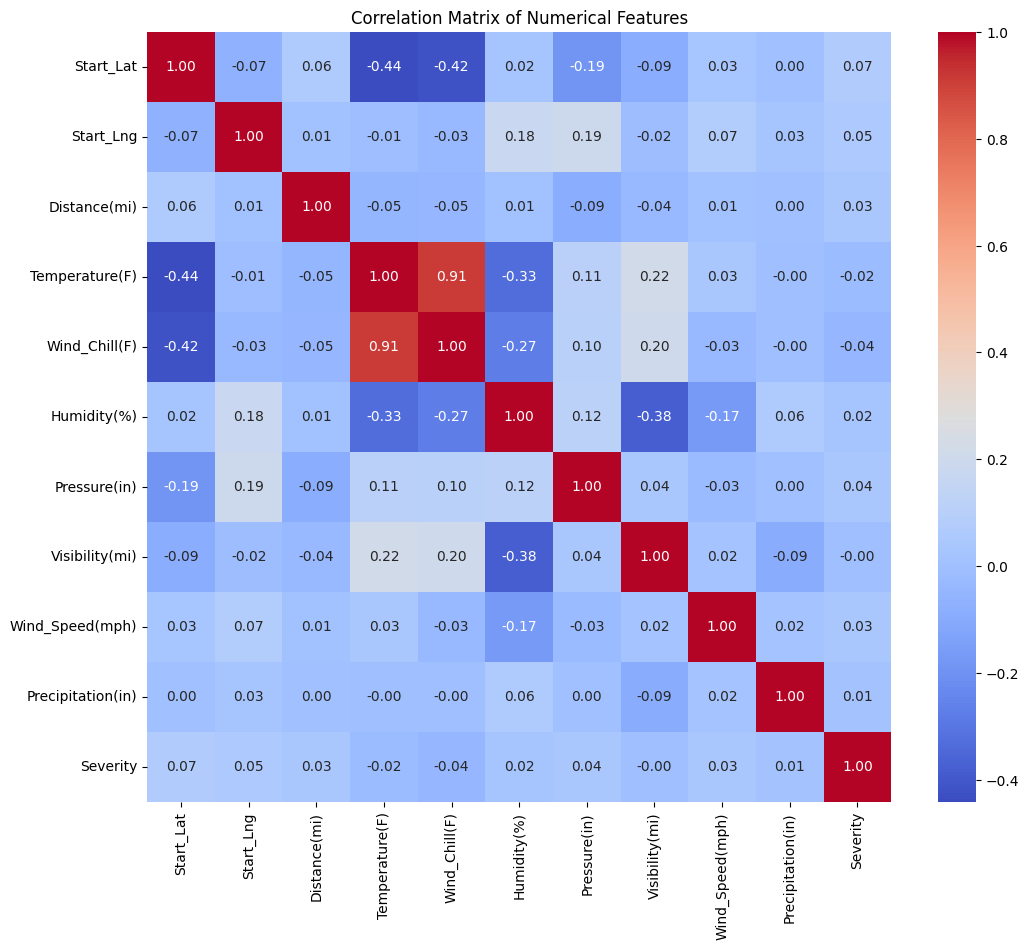

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

numerical_features = [
    'Start_Lat', 'Start_Lng', 'Distance(mi)',
    'Temperature(F)', 'Wind_Chill(F)', 'Humidity(%)',
    'Pressure(in)', 'Visibility(mi)', 'Wind_Speed(mph)', 'Precipitation(in)',
    'Severity'
]

sample_df = df.select(numerical_features).sample(withReplacement=False, fraction=0.1, seed=42)
pandas_df = sample_df.toPandas()

plt.figure(figsize=(12, 10))
sns.heatmap(pandas_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix of Numerical Features")
plt.show()


On remarque que les colonnes `Wind_Chill(F)` et `Temperature(F)` sont tres correlees entres elles, alors on peut en supprimer une des deux

In [4]:
df = df.drop("Wind_Chill(F)")

Pour le choix du model final, on va utiliser un subset du dataframe pour eviter des entrainements trop long lors du choix du model

In [5]:
df_sample = df.sample(fraction=0.1, seed=42)

On fait un split `80/20`

In [6]:
train_data_sample, test_data_sample = df_sample.randomSplit([0.8, 0.2], seed=42)
train_data, test_data = df.randomSplit([0.8, 0.2], seed=42)

In [7]:
# train_data_sample.write.mode("overwrite").parquet("train_data_sample.parquet")
# test_data_sample.write.mode("overwrite").parquet("test_data_sample.parquet")

train_data.write.mode("overwrite").parquet("train_data.parquet")
test_data.write.mode("overwrite").parquet("test_data.parquet")

## Pipeline

In [8]:
feature_cols = columns_to_keep[1:]
feature_cols.remove("Wind_Chill(F)")

On choisie 4 modeles different pour notre analyse que voici:
- Random Forest
- GBT
- Logistic Regression
- OneVsRest avec une base de Logistic Regression

In [11]:
from pyspark.ml.classification import RandomForestClassifier, LogisticRegression, DecisionTreeClassifier, OneVsRest
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.feature import StandardScaler

    
assembler = VectorAssembler(inputCols=feature_cols, outputCol="features")
scaler = StandardScaler(inputCol="features", outputCol="scaledFeatures")

models = {
    "Random Forest": RandomForestClassifier(labelCol="Severity", featuresCol="scaledFeatures"),
    "Logistic Regression": LogisticRegression(labelCol="Severity", featuresCol="scaledFeatures"),
    "Decision Tree": DecisionTreeClassifier(labelCol="Severity", featuresCol="scaledFeatures"),
    "One-vs-Rest": OneVsRest(
        classifier=LogisticRegression(labelCol="Severity", featuresCol="scaledFeatures"),
        labelCol="Severity",
        featuresCol="scaledFeatures"
    )
}

On s'appuie sur le f1-score, le recall et la precision pour comparer nos differents model

In [12]:
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

evaluator_f1 = MulticlassClassificationEvaluator(labelCol="Severity", predictionCol="prediction", metricName="f1")
evaluator_precision = MulticlassClassificationEvaluator(labelCol="Severity", predictionCol="prediction", metricName="weightedPrecision")
evaluator_recall = MulticlassClassificationEvaluator(labelCol="Severity", predictionCol="prediction", metricName="weightedRecall")

In [13]:
from pyspark.ml import Pipeline

def train_and_evaluate(model_name, model, train_data, test_data):
    print(f"Training model: {model_name}")
    pipeline = Pipeline(stages=[assembler, scaler, model])
    pipeline_model = pipeline.fit(train_data)
    predictions = pipeline_model.transform(test_data)
    f1_score = evaluator_f1.evaluate(predictions)
    precision = evaluator_precision.evaluate(predictions)
    recall = evaluator_recall.evaluate(predictions)
    return pipeline_model, f1_score, precision, recall

## Entrainement

In [ ]:
results = {}

for model_name, model in models.items():
    trained_model, f1_score, precision, recall = train_and_evaluate(model_name, model, train_data_sample, test_data_sample)
    results[model_name] = {
        "model": trained_model,
        "f1_score": f1_score,
        "precision": precision,
        "recall": recall
    }

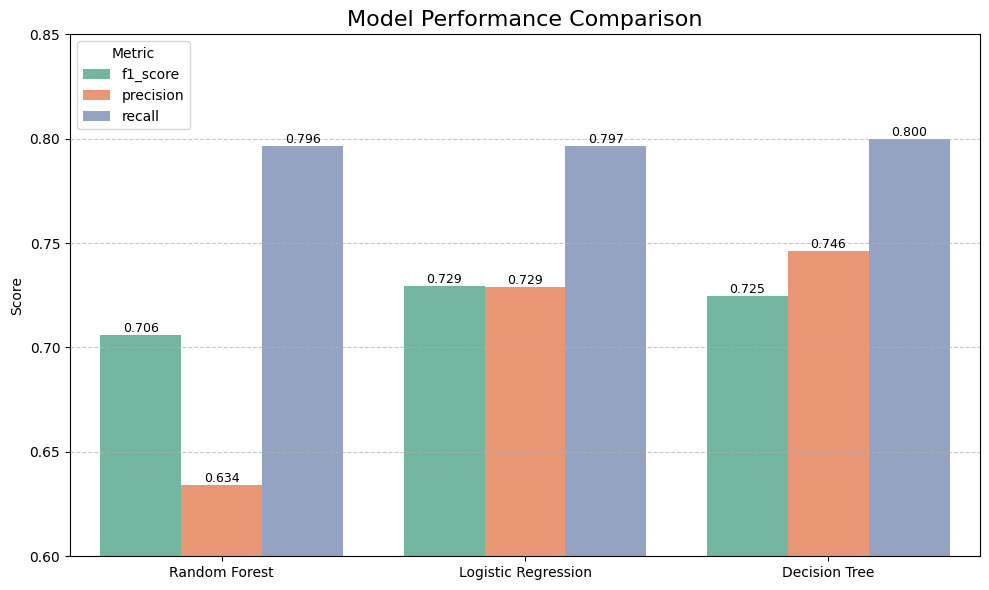

In [15]:
df_results = pd.DataFrame(results).T.reset_index().rename(columns={"index": "Model"})
df_melted = df_results.melt(id_vars="Model", var_name="Metric", value_name="Score")
df_melted = df_melted[df_melted["Metric"] != "model"]
df_melted["Score"] = df_melted["Score"].astype(float)

plt.figure(figsize=(10, 6))
ax = sns.barplot(data=df_melted, x="Model", y="Score", hue="Metric", palette="Set2")

for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", label_type="edge", fontsize=9)

plt.title("Model Performance Comparison", fontsize=16)
plt.ylim(0.6, 0.85)
plt.ylabel("Score")
plt.xlabel("")
plt.legend(title="Metric")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()


D’après tes résultats :
- F1-score le plus élevé : Logistic Regression (≈ 0.729)
- Bonne précision ET rappel

On garde la Logistic Regression pour la suite de l'etude 

## Model final

In [2]:
from pyspark.ml.classification import LogisticRegression
from pyspark.ml.feature import VectorAssembler, StandardScaler, StringIndexer, OneHotEncoder
from pyspark.ml import Pipeline
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder

In [3]:
train = spark.read.parquet("train_data.parquet")
test = spark.read.parquet("test_data.parquet")

feature_cols = train.columns
feature_cols.remove("Severity")

In [4]:
columns_to_encode = [
    "Sunrise_Sunset", "Civil_Twilight", "Nautical_Twilight", "Astronomical_Twilight",
    "Weather_Condition", "Wind_Direction", "State"
]

numerical_features = [col for col in feature_cols if col not in columns_to_encode]

In [5]:
indexers = [StringIndexer(inputCol=col, outputCol=col + "_idx", handleInvalid="keep") for col in columns_to_encode]
encoders = [OneHotEncoder(inputCol=col + "_idx", outputCol=col + "_ohe") for col in columns_to_encode]

assembler_inputs = [col + "_ohe" for col in columns_to_encode] + numerical_features
assembler = VectorAssembler(inputCols=assembler_inputs, outputCol="features")

scaler = StandardScaler(inputCol="features", outputCol="scaled_features")
lr = LogisticRegression(featuresCol="scaled_features", labelCol="Severity", regParam=0.1)

pipeline = Pipeline(stages=indexers + encoders + [assembler, scaler, lr])

In [7]:
model = pipeline.fit(train)

In [8]:
predictions = model.transform(test)

In [9]:
# save the model
model.write().overwrite().save("logistic_regression_model")

In [10]:
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

evaluator = MulticlassClassificationEvaluator(labelCol="Severity", predictionCol="prediction", metricName="f1")
evaluator_precision = MulticlassClassificationEvaluator(labelCol="Severity", predictionCol="prediction", metricName="weightedPrecision")
evaluator_recall = MulticlassClassificationEvaluator(labelCol="Severity", predictionCol="prediction", metricName="weightedRecall")

f1_score = evaluator.evaluate(predictions)
precision_score = evaluator_precision.evaluate(predictions)
recall_score = evaluator_recall.evaluate(predictions)

print(f"F1 Score on test set: {f1_score:.3f}")
print(f"Precision Score on test set: {precision_score:.3f}")
print(f"Recall Score on test set: {recall_score:.3f}")

F1 Score on test set: 0.716
Precision Score on test set: 0.725
Recall Score on test set: 0.797


In [ ]:
indexers = [StringIndexer(inputCol=col, outputCol=col + "_idx", handleInvalid="keep") for col in columns_to_encode]
encoders = [OneHotEncoder(inputCol=col + "_idx", outputCol=col + "_ohe") for col in columns_to_encode]


assembler = VectorAssembler(inputCols=feature_cols,outputCol="features")
scaler = StandardScaler(inputCol="features", outputCol="scaledFeatures")
lr = LogisticRegression(labelCol="Severity", featuresCol="scaledFeatures")

pipeline = Pipeline(stages=[assembler, scaler, lr])

In [8]:
paramGrid = (
    ParamGridBuilder()
    .addGrid(lr.regParam, [0.01, 0.1, 0.5])
    .addGrid(lr.elasticNetParam, [0.0, 0.5, 1.0])
    .build()
)

evaluator = MulticlassClassificationEvaluator(
    labelCol="Severity", predictionCol="prediction", metricName="f1"
)

crossval = CrossValidator(
    estimator=pipeline,
    estimatorParamMaps=paramGrid,
    evaluator=evaluator,
    numFolds=3,
    parallelism=2,
)

In [ ]:
cv_model = crossval.fit(train)

NameError: name 'crossval' is not defined

In [18]:
best_model = cv_model.bestModel

In [ ]:
best_model.write().overwrite().save("final_accident_model")

In [19]:
predictions = best_model.transform(test)

In [23]:
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

evaluator = MulticlassClassificationEvaluator(labelCol="Severity", predictionCol="prediction", metricName="f1")
evaluator_precision = MulticlassClassificationEvaluator(labelCol="Severity", predictionCol="prediction", metricName="weightedPrecision")
evaluator_recall = MulticlassClassificationEvaluator(labelCol="Severity", predictionCol="prediction", metricName="weightedRecall")

f1_score = evaluator.evaluate(predictions)
precision_score = evaluator_precision.evaluate(predictions)
recall_score = evaluator_recall.evaluate(predictions)

print(f"F1 Score on test set: {f1_score:.3f}")
print(f"Precision Score on test set: {precision_score:.3f}")
print(f"Recall Score on test set: {recall_score:.3f}")

F1 Score on test set: 0.728
Precision Score on test set: 0.730
Recall Score on test set: 0.797


In [11]:
spark.stop()